## 0. Libraries

In [1]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [2]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']

In [3]:
# !conda install typing -y

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.func_huang96_biomod import func_huang96_biomod

In [ ]:
def func_huang96_mapk(y, k):
    """
    Huang & Ferrell (1996) MAPK cascade model.

    Parameters
    ----------
    y : ndarray, shape (24,)
        State vector
    k : dict
        Parameters dictionary

    Returns
    -------
    dxdt : ndarray, shape (24,)
        Time derivatives
    """

    # Unpack parameters
    compartment = 4e-12
    a = k[0]
    d = k[1]
    k = k[2]

    # Copy x to avoid in-place modification
    x = np.asarray(y, dtype=float)
    dxdt = np.zeros_like(x)

    # Assignment rule
    # K_PP_norm (index 23)
    denom = (x[10] + x[9] + x[8] + x[17] + x[18] + x[21] + x[22])
    dxdt[23] = 0.0 if denom == 0 else (x[10] + x[21]) / denom

    # Reactions
    r1a = compartment * (a * x[1] * x[3] - d * x[13])
    r1b = compartment * k * x[13]

    r2a = compartment * (a * x[2] * x[4] - d * x[14])
    r2b = compartment * k * x[14]

    r3a = compartment * (a * x[5] * x[4] - d * x[15])
    r3b = compartment * k * x[15]

    r4a = compartment * (a * x[6] * x[12] - d * x[20])
    r4b = compartment * k * x[20]

    r5a = compartment * (a * x[6] * x[4] - d * x[16])
    r5b = compartment * k * x[16]

    r6a = compartment * (a * x[7] * x[12] - d * x[19])
    r6b = compartment * k * x[19]

    r7a = compartment * (a * x[8] * x[7] - d * x[17])
    r7b = compartment * k * x[17]

    r8a = compartment * (a * x[9] * x[11] - d * x[22])
    r8b = compartment * k * x[22]

    r9a = compartment * (a * x[9] * x[7] - d * x[18])
    r9b = compartment * k * x[18]

    r10a = compartment * (a * x[10] * x[11] - d * x[21])
    r10b = compartment * k * x[21]

    # ODEs
    dxdt[1]  = (-r1a + r1b) / compartment
    dxdt[2]  = (-r2a + r2b) / compartment
    dxdt[3]  = (-r1a + r2b) / compartment
    dxdt[4]  = (r1b - r2a - r3a + r3b - r5a + r5b) / compartment
    dxdt[5]  = (-r3a + r4b) / compartment
    dxdt[6]  = (r3b - r4a - r5a + r6b) / compartment
    dxdt[7]  = (r5b - r6a - r7a + r7b - r9a + r9b) / compartment
    dxdt[8]  = (-r7a + r8b) / compartment
    dxdt[9]  = (r7b - r8a - r9a + r10b) / compartment
    dxdt[10] = (r9b - r10a) / compartment
    dxdt[11] = (-r8a + r8b - r10a + r10b) / compartment
    dxdt[12] = (-r4a + r4b - r6a + r6b) / compartment
    dxdt[13] = (r1a - r1b) / compartment
    dxdt[14] = (r2a - r2b) / compartment
    dxdt[15] = (r3a - r3b) / compartment
    dxdt[16] = (r5a - r5b) / compartment
    dxdt[17] = (r7a - r7b) / compartment
    dxdt[18] = (r9a - r9b) / compartment
    dxdt[19] = (r6a - r6b) / compartment
    dxdt[20] = (r4a - r4b) / compartment
    dxdt[21] = (r10a - r10b) / compartment
    dxdt[22] = (r8a - r8b) / compartment

    return np.array(dxdt, dtype=float)


In [6]:
def solve_func_huang96_mapk(y0, t_span, t_eval, arguments, method="BDF"):
    """
    Solve the Huang96 MAPK model.
    """

    sol = solve_ivp(
        fun=lambda t, y: func_huang96_mapk(t, y, arguments),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method=method,
        rtol=1e-6,
        atol=1e-9
    )

    return sol


## 2. Main reproduction

#### **Example 4: Full MAPK cascade model**

The model for the mitogen-activated phosphorylation kinase (MAPK) cascade proposed in [5] captures the first, second and third level of a phosphorylation cascade which occurs for example in epidermal growth factor (EGF) signaling. The kinase on the first level can be reversibly phosphorylated once, the kinases on levels two
and three can be reversibly phosphorylated twice. The phosphorylated kinase of the first level acts as kinase for the phosphorylations on the second level, the double
phosphorylated kinase of the second level acts as kinase for the phosphorylations on the third level. One phosphatase per layer is modelled to mediate dephosphorylation(s). For phosphorylations and dephosphorylations, complex formation between the kinase or phosphatases and the substrate are explicitly included giving rise to ten additional species (the formed complexes). We used the model proposed by Huang-Ferrell [5] with implementation and parameter sets as given in the Biomodels database by Qiao and colleagues [6]. The model contains 22 species.

Initial conditions:

| Si  | Notation (this work) | Original notation | Initial value | Sj  | Notation (this work) | Original notation                | Initial value |
|-----|----------------------|-------------------|---------------|-----|----------------------|----------------------------------|---------------|
| S1  | E1                   | E1                | 3.0E−5        | S13 | E1_KKK               | [E1, MAPKKK]                     | 0.0           |
| S2  | E2                   | E2                | 3.0E−4        | S14 | E2_P_KKK             | [E2, MAPKKK*]                    | 0.0           |
| S3  | KKK                  | MAPKKK            | 0.003         | S15 | P_KKK_KK             | [MAPKKK*, MAPKK]                 | 0.0           |
| S4  | P_KKK                | MAPKKK*           | 0.0           | S16 | P_KKK_P_KK           | [MAPKKK*, MAPKK*]                | 0.0           |
| S5  | KK                   | MAPKK             | 1.2           | S17 | PP_KK_K              | [MAPKK**, MAPK]                  | 0.0           |
| S6  | P_KK                 | MAPKK*            | 0.0           | S18 | PP_KK_P_K            | [MAPKK**, MAPK*]                 | 0.0           |
| S7  | PP_KK                | MAPKK**           | 0.0           | S19 | KK_Pase_PP_KK        | [KKPase, MAPKK**]                | 0.0           |
| S8  | K                    | MAPK              | 1.2           | S20 | KK_Pase_P_KK         | [KKPase, MAPKK*]                 | 0.0           |
| S9  | P_K                  | MAPK*             | 0.0           | S21 | K_Pase_PP_K          | [KPase, MAPK**]                  | 0.0           |
| S10 | PP_K                 | MAPK**            | 0.0           | S22 | K_Pase_P_K           | [KPase, MAPK*]                   | 0.0           |
| S11 | KPase                | KPase             | 0.12          |     |                      |                                  |               |
| S12 | KK_Pase              | KKPase            | 3.0E−4        |     |                      |                                  |               |


##### **ODEs of the model**

22 equations

$$
\begin{aligned}
\frac{dS_1}{dt} &= -k_1\,S_1\,S_3 + k_2\,S_{13} + k_3\,S_{13}, \\[6pt]

\frac{dS_2}{dt} &= -k_4\,S_2\,S_4 + k_5\,S_{14} + k_6\,S_{14}, \\[6pt]

\frac{dS_3}{dt} &= -k_1\,S_1\,S_3 + k_2\,S_{13} + k_6\,S_{14}, \\[6pt]

\frac{dS_4}{dt} &=
k_3\,S_{13}
- k_4\,S_2\,S_4
+ k_5\,S_{14}
- k_7\,S_5\,S_4
+ k_8\,S_{15}
+ k_9\,S_{15} \\[4pt]
&\quad
- k_{13}\,S_6\,S_4
+ k_{14}\,S_{16}
+ k_{15}\,S_{16}, \\[6pt]

\frac{dS_5}{dt} &= -k_7\,S_5\,S_4 + k_8\,S_{15} + k_{12}\,S_{20}, \\[6pt]

\frac{dS_6}{dt} &=
k_9\,S_{15}
- k_{10}\,S_6\,S_{12}
+ k_{11}\,S_{20}
- k_{13}\,S_6\,S_4
+ k_{14}\,S_{16}
+ k_{18}\,S_{19}, \\[6pt]

\frac{dS_7}{dt} &=
k_{15}\,S_{16}
- k_{16}\,S_7\,S_{12}
+ k_{17}\,S_{19}
- k_{19}\,S_8\,S_7
+ k_{20}\,S_{17}
+ k_{21}\,S_{17} \\[4pt]
&\quad
- k_{25}\,S_9\,S_7
+ k_{26}\,S_{18}
+ k_{27}\,S_{18}, \\[6pt]

\frac{dS_8}{dt} &= -k_{19}\,S_8\,S_7 + k_{20}\,S_{17} + k_{24}\,S_{22}, \\[6pt]

\frac{dS_9}{dt} &=
k_{21}\,S_{17}
- k_{22}\,S_9\,S_{11}
+ k_{23}\,S_{22}
- k_{25}\,S_9\,S_7
+ k_{26}\,S_{18}
+ k_{30}\,S_{21}, \\[6pt]

\frac{dS_{10}}{dt} &= k_{27}\,S_{18} - k_{28}\,S_{10}\,S_{11} + k_{29}\,S_{21}, \\[6pt]

\frac{dS_{11}}{dt} &=
- k_{22}\,S_9\,S_{11}
+ k_{23}\,S_{22}
+ k_{24}\,S_{22}
- k_{28}\,S_{10}\,S_{11}
+ k_{29}\,S_{21}
+ k_{30}\,S_{21}, \\[6pt]

\frac{dS_{12}}{dt} &=
- k_{10}\,S_6\,S_{12}
+ k_{11}\,S_{20}
+ k_{12}\,S_{20}
- k_{16}\,S_7\,S_{12}
+ k_{17}\,S_{19}
+ k_{18}\,S_{19}, \\[6pt]

\frac{dS_{13}}{dt} &= k_1\,S_1\,S_3 - k_2\,S_{13} - k_3\,S_{13}, \\[6pt]

\frac{dS_{14}}{dt} &= k_4\,S_2\,S_4 - k_5\,S_{14} - k_6\,S_{14}, \\[6pt]

\frac{dS_{15}}{dt} &= k_7\,S_5\,S_4 - k_8\,S_{15} - k_9\,S_{15}, \\[6pt]

\frac{dS_{16}}{dt} &= k_{13}\,S_6\,S_4 - k_{14}\,S_{16} - k_{15}\,S_{16}, \\[6pt]

\frac{dS_{17}}{dt} &= k_{19}\,S_8\,S_7 - k_{20}\,S_{17} - k_{21}\,S_{17}, \\[6pt]

\frac{dS_{18}}{dt} &= k_{25}\,S_9\,S_7 - k_{26}\,S_{18} - k_{27}\,S_{18}, \\[6pt]

\frac{dS_{19}}{dt} &= k_{16}\,S_7\,S_{12} - k_{17}\,S_{19} - k_{18}\,S_{19}, \\[6pt]

\frac{dS_{20}}{dt} &= k_{10}\,S_6\,S_{12} - k_{11}\,S_{20} - k_{12}\,S_{20}, \\[6pt]

\frac{dS_{21}}{dt} &= k_{28}\,S_{10}\,S_{11} - k_{29}\,S_{21} - k_{30}\,S_{21}, \\[6pt]

\frac{dS_{22}}{dt} &= k_{22}\,S_9\,S_{11} - k_{23}\,S_{22} - k_{24}\,S_{22}.
\end{aligned}
$$

##### **Parameter**

 Reaction rate parameters

| Reaction        | Parameter | Value  | Reaction        | Parameter | Value | Reaction        | Parameter | Value |
|-----------------|-----------|--------|-----------------|-----------|-------|-----------------|-----------|-------|
| rct_r1a_a1      | k1        | 1000.0 | rct_r1a_d1      | k2        | 150.0 | rct_r1b_k2      | k3        | 150.0 |
| rct_r2a_a2      | k4        | 1000.0 | rct_r2a_d2      | k5        | 150.0 | rct_r2b_k2      | k6        | 150.0 |
| rct_r3a_a3      | k7        | 1000.0 | rct_r3a_d3      | k8        | 150.0 | rct_r3b_k3      | k9        | 150.0 |
| rct_r4a_a4      | k10       | 1000.0 | rct_r4a_d4      | k11       | 150.0 | rct_r4b_k4      | k12       | 150.0 |
| rct_r5a_a5      | k13       | 1000.0 | rct_r5a_d5      | k14       | 150.0 | rct_r5b_k5      | k15       | 150.0 |
| rct_r6a_a6      | k16       | 1000.0 | rct_r6a_d6      | k17       | 150.0 | rct_r6b_k6      | k18       | 150.0 |
| rct_r7a_a7      | k19       | 1000.0 | rct_r7a_d7      | k20       | 150.0 | rct_r7b_k7      | k21       | 150.0 |
| rct_r8a_a8      | k22       | 1000.0 | rct_r8a_d8      | k23       | 150.0 | rct_r8b_k8      | k24       | 150.0 |
| rct_r9a_a9      | k25       | 1000.0 | rct_r9a_d9      | k26       | 150.0 | rct_r9b_k9      | k27       | 150.0 |
| rct_r10a_a10    | k28       | 1000.0 | rct_r10a_d10    | k29       | 150.0 | rct_r10b_k10    | k30       | 150.0 |


In [3]:
def model_MAPK_22(y, k):
    S1, S2, S3, S4, S5, S6, S7, S8, S9, S10, \
    S11, S12, S13, S14, S15, S16, S17, S18, S19, S20, \
    S21, S22 = y

    k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, \
    k11, k12, k13, k14, k15, k16, k17, k18, k19, k20, \
    k21, k22, k23, k24, k25, k26, k27, k28, k29, k30 = k

    dS1  = -k1*S1*S3 + k2*S13 + k3*S13
    dS2  = -k4*S2*S4 + k5*S14 + k6*S14
    dS3  = -k1*S1*S3 + k2*S13 + k6*S14

    dS4  = (k3*S13 - k4*S2*S4 + k5*S14
            - k7*S5*S4 + k8*S15 + k9*S15
            - k13*S6*S4 + k14*S16 + k15*S16)

    dS5  = -k7*S5*S4 + k8*S15 + k12*S20

    dS6  = (k9*S15 - k10*S6*S12 + k11*S20
            - k13*S6*S4 + k14*S16 + k18*S19)

    dS7  = (k15*S16 - k16*S7*S12 + k17*S19
            - k19*S8*S7 + k20*S17 + k21*S17
            - k25*S9*S7 + k26*S18 + k27*S18)

    dS8  = -k19*S8*S7 + k20*S17 + k24*S22

    dS9  = (k21*S17 - k22*S9*S11 + k23*S22
            - k25*S9*S7 + k26*S18 + k30*S21)

    dS10 = k27*S18 - k28*S10*S11 + k29*S21

    dS11 = (-k22*S9*S11 + k23*S22 + k24*S22
            - k28*S10*S11 + k29*S21 + k30*S21)

    dS12 = (-k10*S6*S12 + k11*S20 + k12*S20
            - k16*S7*S12 + k17*S19 + k18*S19)

    dS13 = k1*S1*S3 - k2*S13 - k3*S13
    dS14 = k4*S2*S4 - k5*S14 - k6*S14
    dS15 = k7*S5*S4 - k8*S15 - k9*S15
    dS16 = k13*S6*S4 - k14*S16 - k15*S16
    dS17 = k19*S8*S7 - k20*S17 - k21*S17
    dS18 = k25*S9*S7 - k26*S18 - k27*S18
    dS19 = k16*S7*S12 - k17*S19 - k18*S19
    dS20 = k10*S6*S12 - k11*S20 - k12*S20
    dS21 = k28*S10*S11 - k29*S21 - k30*S21
    dS22 = k22*S9*S11 - k23*S22 - k24*S22

    return np.array([
        dS1, dS2, dS3, dS4, dS5, dS6, dS7, dS8, dS9, dS10,
        dS11, dS12, dS13, dS14, dS15, dS16, dS17, dS18,
        dS19, dS20, dS21, dS22
    ], dtype=float)

def solve_MAPK_22(initial_conditions, time_points, params):
    sol = solve_ivp(lambda t, y: model_MAPK_22(y, params),
                    [time_points[0], time_points[-1]],
                    initial_conditions,
                    t_eval=time_points,
                    method='LSODA')
    return sol

In [4]:
# Parameters from supplementary material
# Reaction rate constants (k1 ... k30)
k = np.array([
    1000.0, 150.0, 150.0,   # k1  k2  k3
    1000.0, 150.0, 150.0,   # k4  k5  k6
    1000.0, 150.0, 150.0,   # k7  k8  k9
    1000.0, 150.0, 150.0,   # k10 k11 k12
    1000.0, 150.0, 150.0,   # k13 k14 k15
    1000.0, 150.0, 150.0,   # k16 k17 k18
    1000.0, 150.0, 150.0,   # k19 k20 k21
    1000.0, 150.0, 150.0,   # k22 k23 k24
    1000.0, 150.0, 150.0,   # k25 k26 k27
    1000.0, 150.0, 150.0    # k28 k29 k30
], dtype=float)

# Initial conditions for S1 ... S22 (from the table)
y0_0 = np.array([
    3.0e-5,   # S1  (E1)
    3.0e-4,   # S2  (E2)
    0.003,    # S3  (KKK / MAPKKK)
    0.0,      # S4  (P_KKK / MAPKKK*)
    1.2,      # S5  (KK / MAPKK)
    0.0,      # S6  (P_KK / MAPKK*)
    0.0,      # S7  (PP_KK / MAPKK**)
    1.2,      # S8  (K / MAPK)
    0.0,      # S9  (P_K / MAPK*)
    0.0,      # S10 (PP_K / MAPK**)
    0.12,     # S11 (KPase)
    3.0e-4,   # S12 (KK_Pase / KKPase)
    0.0,      # S13 (E1_KKK)
    0.0,      # S14 (E2_P_KKK)
    0.0,      # S15 (P_KKK_KK)
    0.0,      # S16 (P_KKK_P_KK)
    0.0,      # S17 (PP_KK_K)
    0.0,      # S18 (PP_KK_P_K)
    0.0,      # S19 (KKPase_PP_KK)
    0.0,      # S20 (KKPase_P_KK)
    0.0,      # S21 (KPase_PP_K)
    0.0       # S22 (KPase_P_K)
], dtype=float)

labels = ["E1", "E2", "MAPKKK", "MAPKKK*", "MAPKK", "MAPKK*", "MAPKK**", "MAPK", "MAPK*", "MAPK**", "KPase", "KK_Pase", "E1_KKK", "E2_P_KKK", "P_KKK_KK", "P_KKK_P_KK", "PP_KK_K", "PP_KK_P_K", "KKPase_PP_KK", "KKPase_P_KK", "KPase_PP_K", "KPase_P_K"]

# Parameters not yet in supplement data
# perturbation_point = 0.2

### 2.1. First parameter set (original)

In [6]:
# Jacocbian calculation
j_matrix = numdifftools.Jacobian(lambda x: model_MAPK_22(x, k),method="central")(y0_0)
signed_jacobian = np.sign(j_matrix)

In [7]:
# print("Jacobian matrix:")
# pd.DataFrame(j_matrix, index=labels, columns=labels)

In [8]:
# print("Signed Jacobian matrix:")
# pd.DataFrame(signed_jacobian, index=labels, columns=labels)

In [9]:
time_points = np.linspace(0, 1100, 1100)
sol = solve_MAPK_22(y0_0, time_points, k)

In [10]:
# Find loops at t=1100
res_tab_complex = ld.find_loops_vset(model_MAPK_22,
                                     vset=[sol.y[:, -1]],
                                     k=k,
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])

                        loop  length  sign
0                  (0, 2, 0)       2     1
1              (0, 2, 12, 0)       3    -1
2                 (0, 12, 0)       2     1
3              (0, 12, 2, 0)       3    -1
4    (0, 12, 3, 1, 13, 2, 0)       6     1
..                       ...     ...   ...
183                 (17, 17)       1    -1
184                 (18, 18)       1    -1
185                 (19, 19)       1    -1
186                 (20, 20)       1    -1
187                 (21, 21)       1    -1

[188 rows x 3 columns]


In [13]:
ld.loop_summary(res_tab_complex['loop_rep'][0])

length,1,2,3,4,5,6,7,8,9
total,22,30,24,17,26,19,16,22,12
neg,22,0,24,0,26,0,16,0,12
pos,0,30,0,17,0,19,0,22,0


### 2.2. Second parameter set (oscillation behavior)

In [27]:
def func_huang96_biomod_p1(y):
    """
    Python translation of MATLAB/Octave:
        func_huang96_biomod_p1(t, x)

    Notes
    -----
    - MATLAB code uses 1-based indices and allocates xdot as length 26.
      Here we use 0-based indices and return a (26,) ndarray.
    - The "assignmentRule" variables are treated the same way as in the MATLAB:
      x[22], x[23], x[24], x[25] correspond to x(23:26).
    - The MATLAB code writes xdot(23)=x(23) etc. (i.e., not true ODE states but rule outputs).
      This function reproduces that behavior exactly.
    """

    # Copy state to avoid in-place edits
    x = np.asarray(y, dtype=float).copy()

    # Ensure we have 26 slots (MATLAB uses x(1..26) with rules stored in 23..26)
    if x.shape[0] < 26:
        x = np.pad(x, (0, 26 - x.shape[0]), mode="constant")
    elif x.shape[0] > 26:
        x = x[:26]

    # Compartment and global parameter
    compartment = 4.0e-12
    K_PP_norm_max = 0.900049

    # ---- Assignment rules (MATLAB x(23..26)) ----
    # MATLAB: x(23)=(x(10)+x(21))/(x(10)+x(9)+x(8)+x(17)+x(18)+x(21)+x(22));
    denom_K_PP = (x[9] + x[8] + x[7] + x[16] + x[17] + x[20] + x[21])
    x[22] = 0.0 if denom_K_PP == 0.0 else (x[9] + x[20]) / denom_K_PP  # K_PP_norm

    # MATLAB: x(26)=x(23)/global_par_K_PP_norm_max;
    x[25] = 0.0 if K_PP_norm_max == 0.0 else x[22] / K_PP_norm_max     # rel_K_PP_max

    # MATLAB: x(24)=(x(7)+x(17)+x(18)+x(19))/(x(7)+x(6)+x(5)+x(17)+x(18)+x(15)+x(16)+x(19)+x(20));
    denom_KK_PP = (x[6] + x[5] + x[4] + x[16] + x[17] + x[14] + x[15] + x[18] + x[19])
    x[23] = 0.0 if denom_KK_PP == 0.0 else (x[6] + x[16] + x[17] + x[18]) / denom_KK_PP  # KK_PP_norm

    # MATLAB: x(25)=(x(4)+x(15)+x(16))/(x(3)+x(4)+x(15)+x(16));
    denom_KKK_P = (x[2] + x[3] + x[14] + x[15])
    x[24] = 0.0 if denom_KKK_P == 0.0 else (x[3] + x[14] + x[15]) / denom_KKK_P  # KKK_P_norm

    # ---- Reactions (exact numeric parameters from MATLAB) ----
    # r1a
    r1a_a1 = 1096.2
    r1a_d1 = 43.207
    r1a = compartment * (r1a_a1 * x[0] * x[2] - r1a_d1 * x[12])

    # r1b
    r1b_k2 = 69.525
    r1b = compartment * r1b_k2 * x[12]

    # r2a
    r2a_a2 = 1557.6
    r2a_d2 = 94.394
    r2a = compartment * (r2a_a2 * x[1] * x[3] - r2a_d2 * x[13])

    # r2b
    r2b_k2 = 288.74
    r2b = compartment * r2b_k2 * x[13]

    # r3a
    r3a_a3 = 1917.9
    r3a_d3 = 75.216
    r3a = compartment * (r3a_a3 * x[4] * x[3] - r3a_d3 * x[14])

    # r3b
    r3b_k3 = 43.432
    r3b = compartment * r3b_k3 * x[14]

    # r4a
    r4a_a4 = 368.94
    r4a_d4 = 417.1
    r4a = compartment * (r4a_a4 * x[5] * x[11] - r4a_d4 * x[19])

    # r4b
    r4b_k4 = 715.05
    r4b = compartment * r4b_k4 * x[19]

    # r5a
    r5a_a5 = 4583.6
    r5a_d5 = 337.42
    r5a = compartment * (r5a_a5 * x[5] * x[3] - r5a_d5 * x[15])

    # r5b
    r5b_k5 = 169.57
    r5b = compartment * r5b_k5 * x[15]

    # r6a
    r6a_a6 = 2021.9
    r6a_d6 = 439.05
    r6a = compartment * (r6a_a6 * x[6] * x[11] - r6a_d6 * x[18])

    # r6b
    r6b_k6 = 348.42
    r6b = compartment * r6b_k6 * x[18]

    # r7a
    r7a_a7 = 2663.4
    r7a_d7 = 59.598
    r7a = compartment * (r7a_a7 * x[7] * x[6] - r7a_d7 * x[16])

    # r7b
    r7b_k7 = 41.954
    r7b = compartment * r7b_k7 * x[16]

    # r8a
    r8a_a8 = 1443.5
    r8a_d8 = 40.101
    r8a = compartment * (r8a_a8 * x[8] * x[10] - r8a_d8 * x[21])

    # r8b
    r8b_k8 = 63.433
    r8b = compartment * r8b_k8 * x[21]

    # r9a
    r9a_a9 = 543.66
    r9a_d9 = 222.11
    r9a = compartment * (r9a_a9 * x[8] * x[6] - r9a_d9 * x[17])

    # r9b
    r9b_k9 = 117.16
    r9b = compartment * r9b_k9 * x[17]

    # r10a
    r10a_a10 = 439.9
    r10a_d10 = 176.42
    r10a = compartment * (r10a_a10 * x[9] * x[10] - r10a_d10 * x[20])

    # r10b
    r10b_k10 = 46.705
    r10b = compartment * r10b_k10 * x[20]

    # ---- ODEs (xdot 1..22) ----
    dxdt = np.zeros(26, dtype=float)

    dxdt[0]  = (-r1a + r1b) / compartment
    dxdt[1]  = (-r2a + r2b) / compartment
    dxdt[2]  = (-r1a + r2b) / compartment
    dxdt[3]  = ( r1b - r2a - r3a + r3b - r5a + r5b) / compartment
    dxdt[4]  = (-r3a + r4b) / compartment
    dxdt[5]  = ( r3b - r4a - r5a + r6b) / compartment
    dxdt[6]  = ( r5b - r6a - r7a + r7b - r9a + r9b) / compartment
    dxdt[7]  = (-r7a + r8b) / compartment
    dxdt[8]  = ( r7b - r8a - r9a + r10b) / compartment
    dxdt[9]  = ( r9b - r10a) / compartment
    dxdt[10] = (-r8a + r8b - r10a + r10b) / compartment
    dxdt[11] = (-r4a + r4b - r6a + r6b) / compartment
    dxdt[12] = ( r1a - r1b) / compartment
    dxdt[13] = ( r2a - r2b) / compartment
    dxdt[14] = ( r3a - r3b) / compartment
    dxdt[15] = ( r5a - r5b) / compartment
    dxdt[16] = ( r7a - r7b) / compartment
    dxdt[17] = ( r9a - r9b) / compartment
    dxdt[18] = ( r6a - r6b) / compartment
    dxdt[19] = ( r4a - r4b) / compartment
    dxdt[20] = ( r10a - r10b) / compartment
    dxdt[21] = ( r8a - r8b) / compartment

    # ---- "Rule species" outputs (MATLAB sets xdot(23..26) = x(23..26)) ----
    dxdt[22] = x[22]  # K_PP_norm
    dxdt[23] = x[23]  # KK_PP_norm
    dxdt[24] = x[24]  # KKK_P_norm
    dxdt[25] = x[25]  # rel_K_PP_max

    return dxdt

def solve_huang_biomod_p1 (t, y0):
    """
    Solve Huang & Ferrell (1996) MAPK cascade model.

    Parameters
    ----------
    t : ndarray
        Time points
    y0 : ndarray, shape (24,)
        Initial conditions
    k : dict
        Parameters dictionary

    Returns
    -------
    sol : OdeResult
        Solution object from scipy.integrate.solve_ivp
    """
    sol = solve_ivp(lambda t, y: func_huang96_biomod_p1(y), (t[0], t[-1]), y0, t_eval=t, method='RK45')
    return sol

In [20]:
# Copy y0_0 to y0_1 and change only a few initial conditions
# xini=zeros(26,1);
# xini(1)=1e-07;
# xini(2)=1.2115e-04;
# xini(3)=3.7122e-03;
# xini(5)=4.0658;
# xini(12)=9.4579e-05;
# xini(11)=7.5372e-02;
# xini(8)=2;
# The figure starts at t=9000.

y0_1 = y0_0.copy()
y0_1[0] = 1e-07  # Decrease
y0_1[1] = 1.2115e-4  # Decrease
y0_1[2] = 3.7122e-3  # Decrease
y0_1[4] = 4.0658  # Increase
y0_1[7] = 2.0  # Increase
y0_1[10] = 7.5372e-2  # Increase
y0_1[11] = 9.4579e-5  # Decrease

# create new variable by copy y0_1 and add S23-26 = 0 
y0_1_1 = y0_1.copy()
y0_1_1 = np.append(y0_1_1, [0, 0, 0, 0])

In [ ]:
# Initial simulation to stablize the system
time_points = np.linspace(0, 9000, 9001)
# sol = solve_MAPK_22(y0_1, time_points, k)
sol = solve_huang_biomod_p1(time_points, y0_1_1)

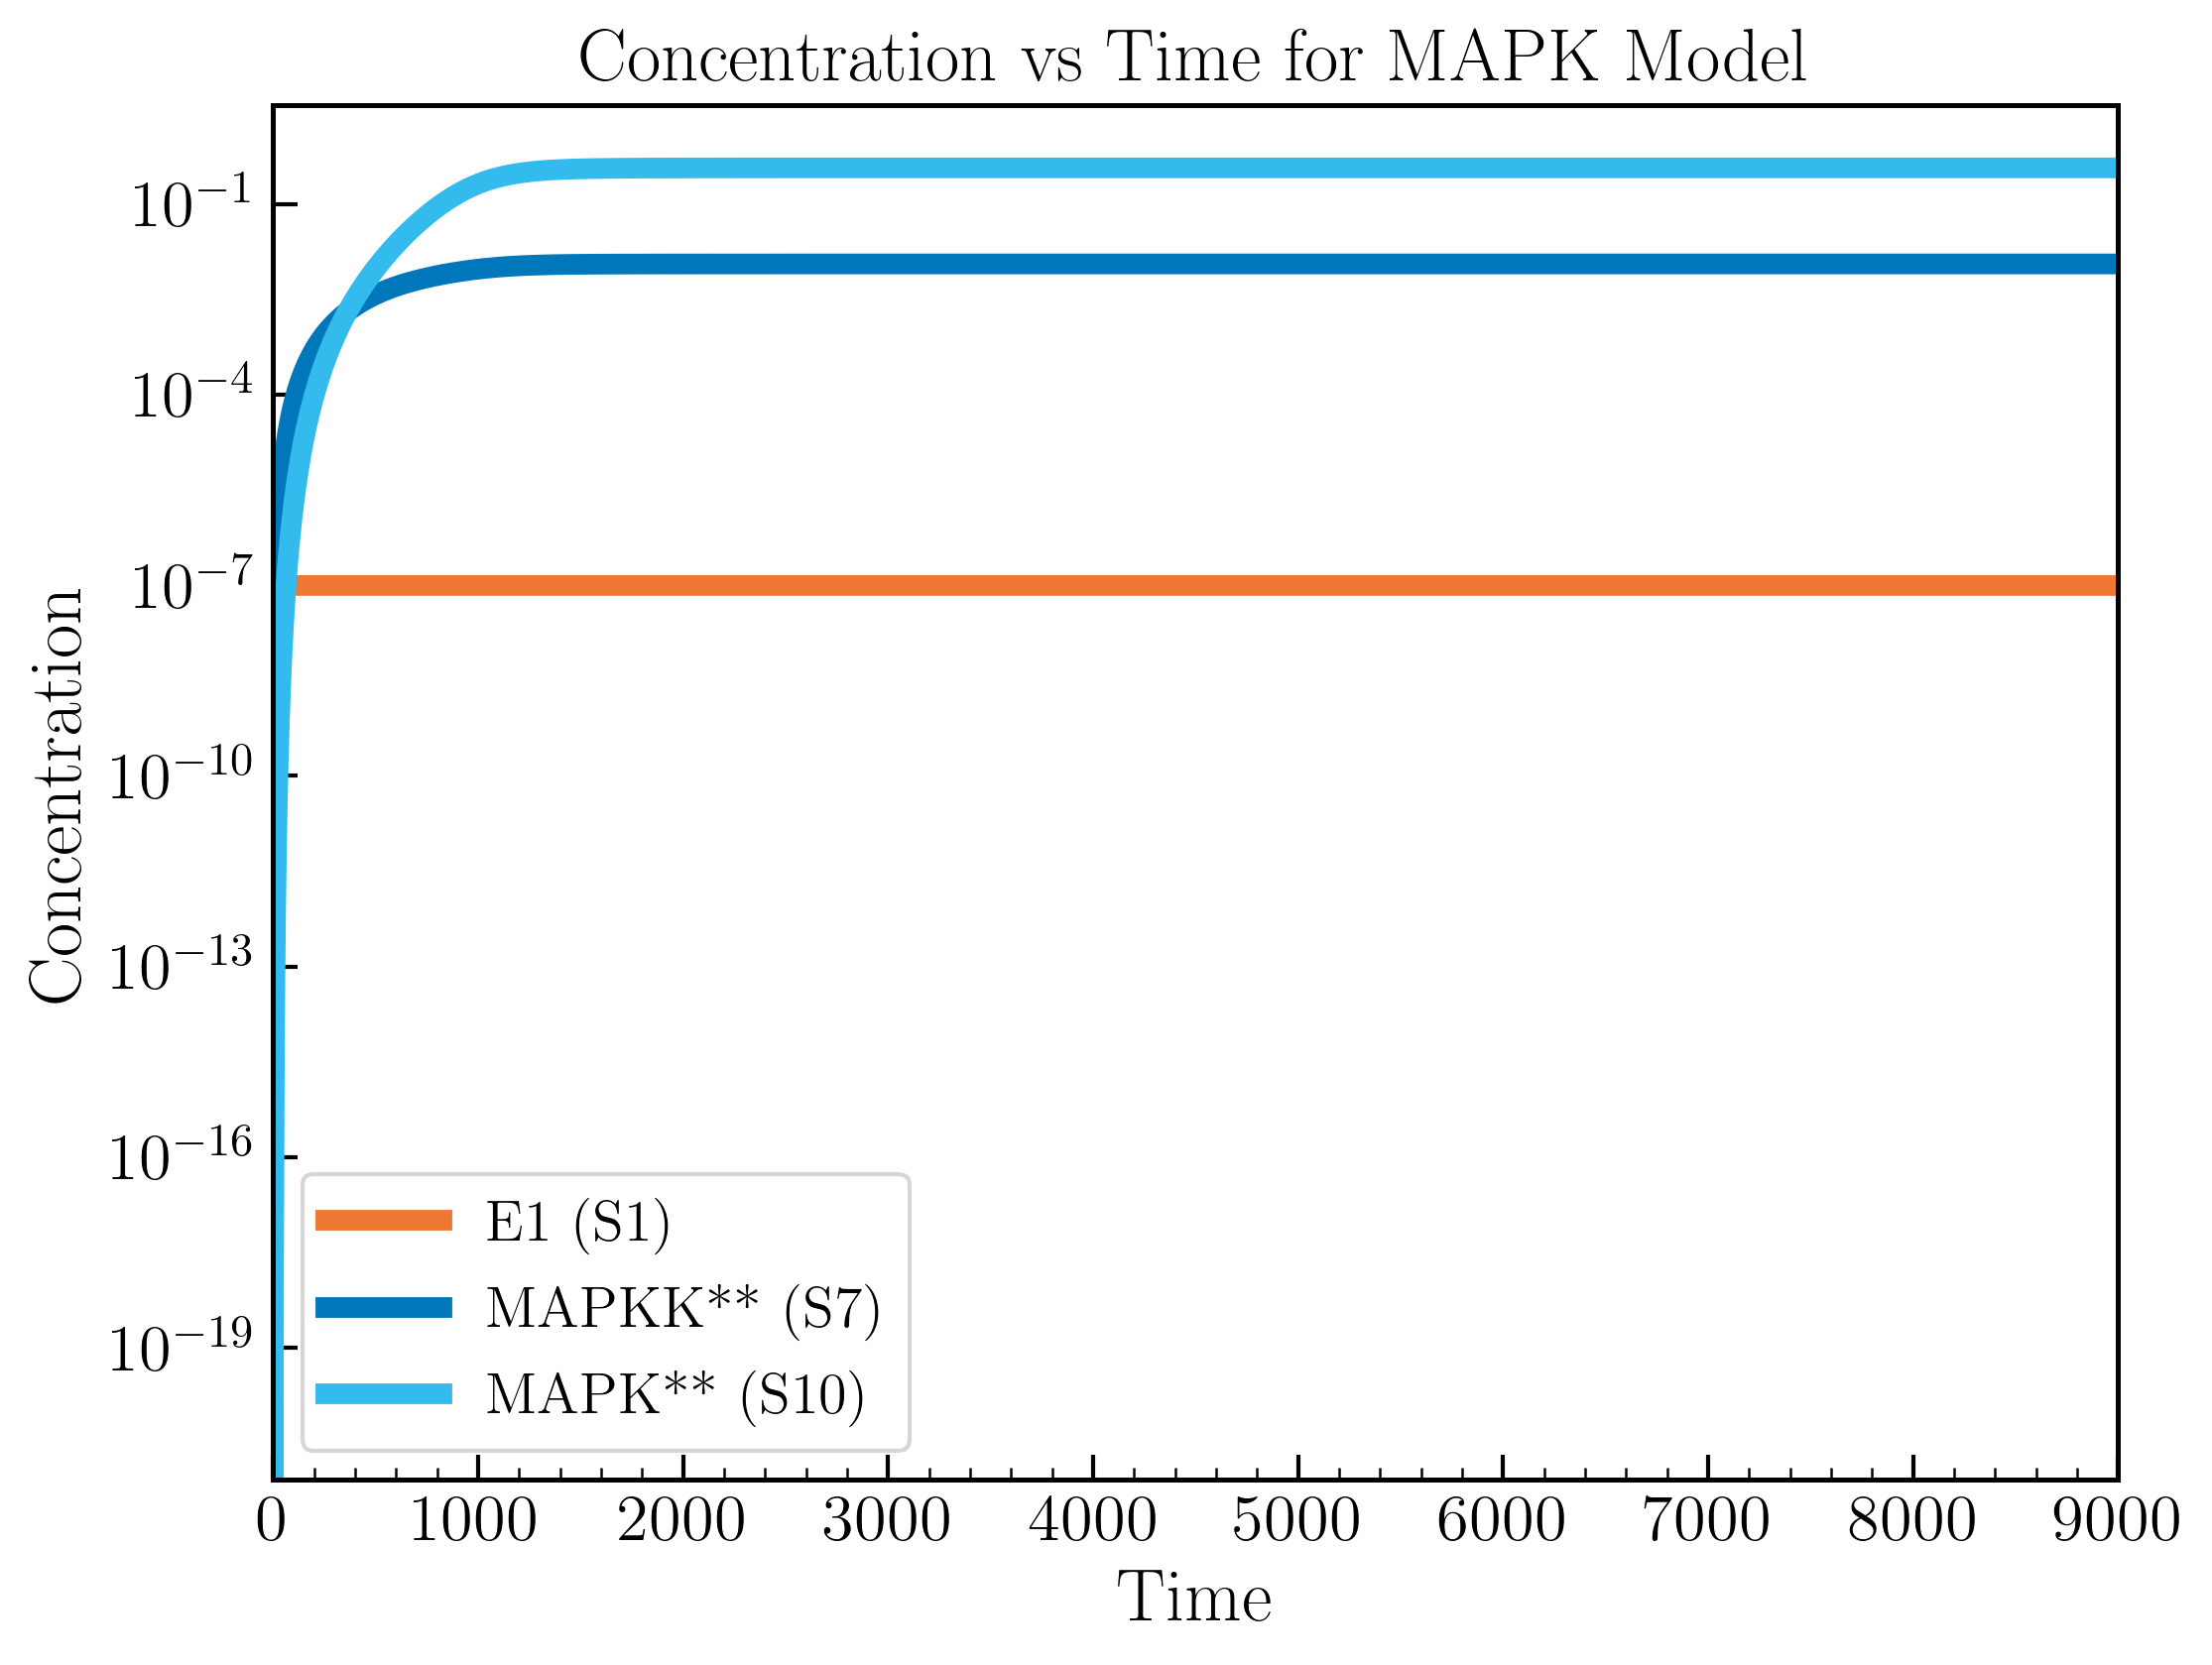

In [17]:
plt.figure(figsize=(8, 6))
investigate_label = ['E1 (S1)', 'MAPKK** (S7)', 'MAPK** (S10)']
investigate_index = [0, 6, 9]
for i, c in enumerate(colors[:3]):
    plt.plot(time_points, sol.y[investigate_index[i]], lw=5, color=c, label=investigate_label[i])
# plt.plot(sol.t, sol.y.T)
# plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
plt.xlim(0, 9000)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for MAPK Model')
plt.legend(investigate_label)
plt.show()

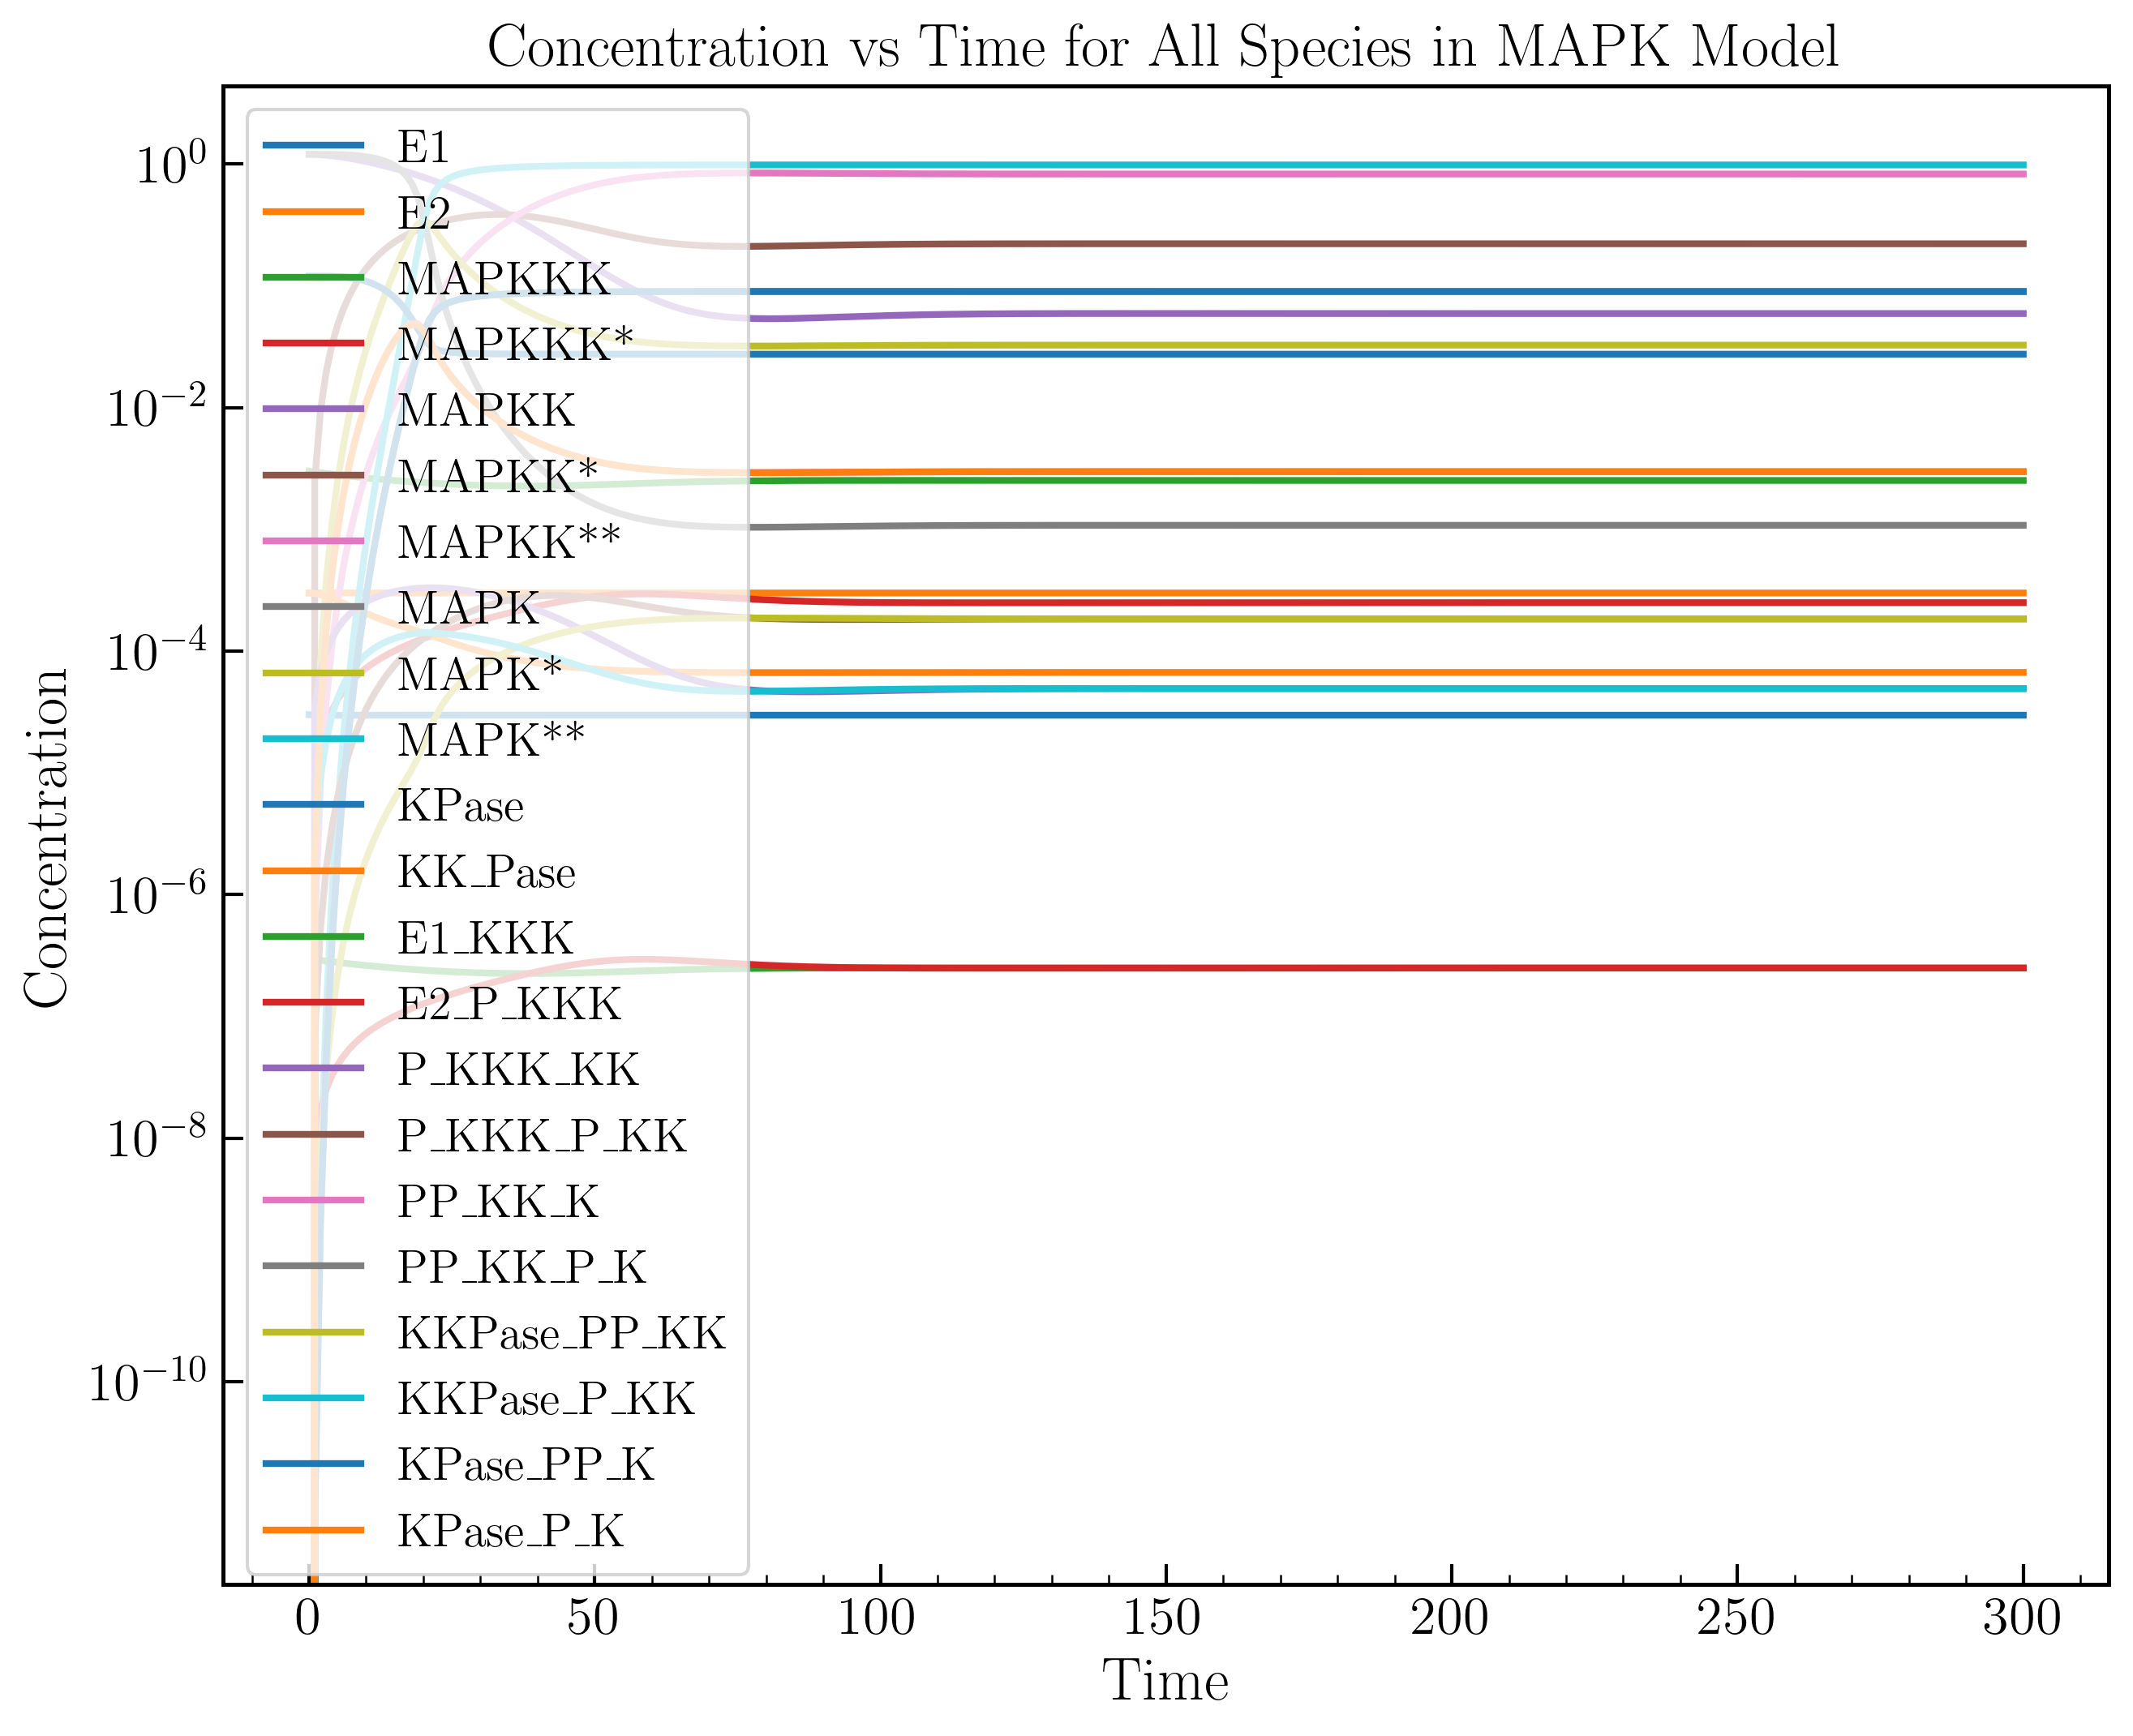

In [14]:
# Plot all species
plt.figure(figsize=(10, 8))
for i in range(22):
    plt.plot(time_points, sol.y[i], lw=2, label=labels[i])
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for All Species in MAPK Model')
plt.legend()
plt.show()

### 2.2. Try the Huang96 MAPK model (provided by Prof. Baum)

In [11]:
y0_2 = np.concatenate([y0, np.array([0.0, 0.0])])  # Append zeros for S21 and S22

In [13]:
# Jacobian calculation for Huang96 MAPK model
j_matrix_mapk = numdifftools.Jacobian(lambda x: func_huang96_mapk(0, x, {
    "compartment": 1.0,
    "a_pars": 1000.0,
    "d_pars": 150.0,
    "k_pars": 150.0,
}))(y0_2)
signed_jacobian_mapk = np.sign(j_matrix_mapk)


In [14]:
print("Jacobian matrix MAPK:")
pd.DataFrame(j_matrix_mapk, index=[f'S{i+1}' for i in range(24)], columns=[f'S{i+1}' for i in range(24)])

Jacobian matrix MAPK:
Signed Jacobian matrix MAPK:


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S15,S16,S17,S18,S19,S20,S21,S22,S23,S24
S1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S2,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S3,0.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S4,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S5,0.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S6,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
S7,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
S8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
S9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
S10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0


In [17]:
print("Signed Jacobian matrix MAPK:")
pd.DataFrame(signed_jacobian_mapk, index=[f'S{i+1}' for i in range(24)], columns=[f'S{i+1}' for i in range(24)])

Signed Jacobian matrix MAPK:


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S15,S16,S17,S18,S19,S20,S21,S22,S23,S24
S1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S2,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S3,0.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S4,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S5,0.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S6,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
S7,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
S8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
S9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
S10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0


In [19]:
def wrap_drop_time_for_loopdetect(func, t0=0.0):
    """
    Convert func(t, x, arguments) -> g(x, arguments)
    Ensures output is a 1D float array (important for downstream code).
    """
    def g(x, arguments):
        x = np.asarray(x, dtype=float).reshape(-1)
        out = func(t0, x, arguments)
        return np.asarray(out, dtype=float).reshape(-1)
    return g

func_mapk_ld = wrap_drop_time_for_loopdetect(func_huang96_mapk, t0=0.0)

In [20]:
# Find loops in Huang96 MAPK model
res_tab_mapk = ld.find_loops_vset(func_mapk_ld, 
                                  vset=[y0_2],
                                  arguments={
    "compartment": 1.0,
    "a_pars": 1000.0,
    "d_pars": 150.0,
    "k_pars": 150.0,
})
print(res_tab_mapk['loop_rep'][0])

                      loop  length  sign
0                (2, 4, 2)       2     1
1            (2, 4, 14, 2)       3    -1
2               (2, 14, 2)       2     1
3     (2, 14, 3, 13, 4, 2)       5    -1
4            (2, 14, 4, 2)       3    -1
5               (3, 13, 3)       2     1
6        (3, 13, 4, 14, 3)       4     1
7               (4, 14, 4)       2     1
8              (16, 6, 16)       2     1
9               (5, 15, 5)       2     1
10              (8, 17, 8)       2     1
11       (8, 17, 9, 22, 8)       4     1
12      (9, 11, 10, 21, 9)       4     1
13          (9, 11, 21, 9)       3    -1
14              (9, 18, 9)       2     1
15  (9, 18, 10, 11, 21, 9)       5    -1
16      (9, 18, 10, 21, 9)       4     1
17              (9, 22, 9)       2     1
18  (9, 22, 11, 10, 21, 9)       5    -1
19      (9, 22, 11, 21, 9)       4     1
20            (10, 11, 10)       2     1
21        (10, 11, 21, 10)       3    -1
22            (10, 21, 10)       2     1
23        (10, 2

In [21]:
loop_list = ld.find_loops(j_matrix_mapk)
ld.loop_summary(loop_list)

length,1,2,3,4,5
total,20,13,5,5,3
neg,20,0,5,0,3
pos,0,13,0,5,0


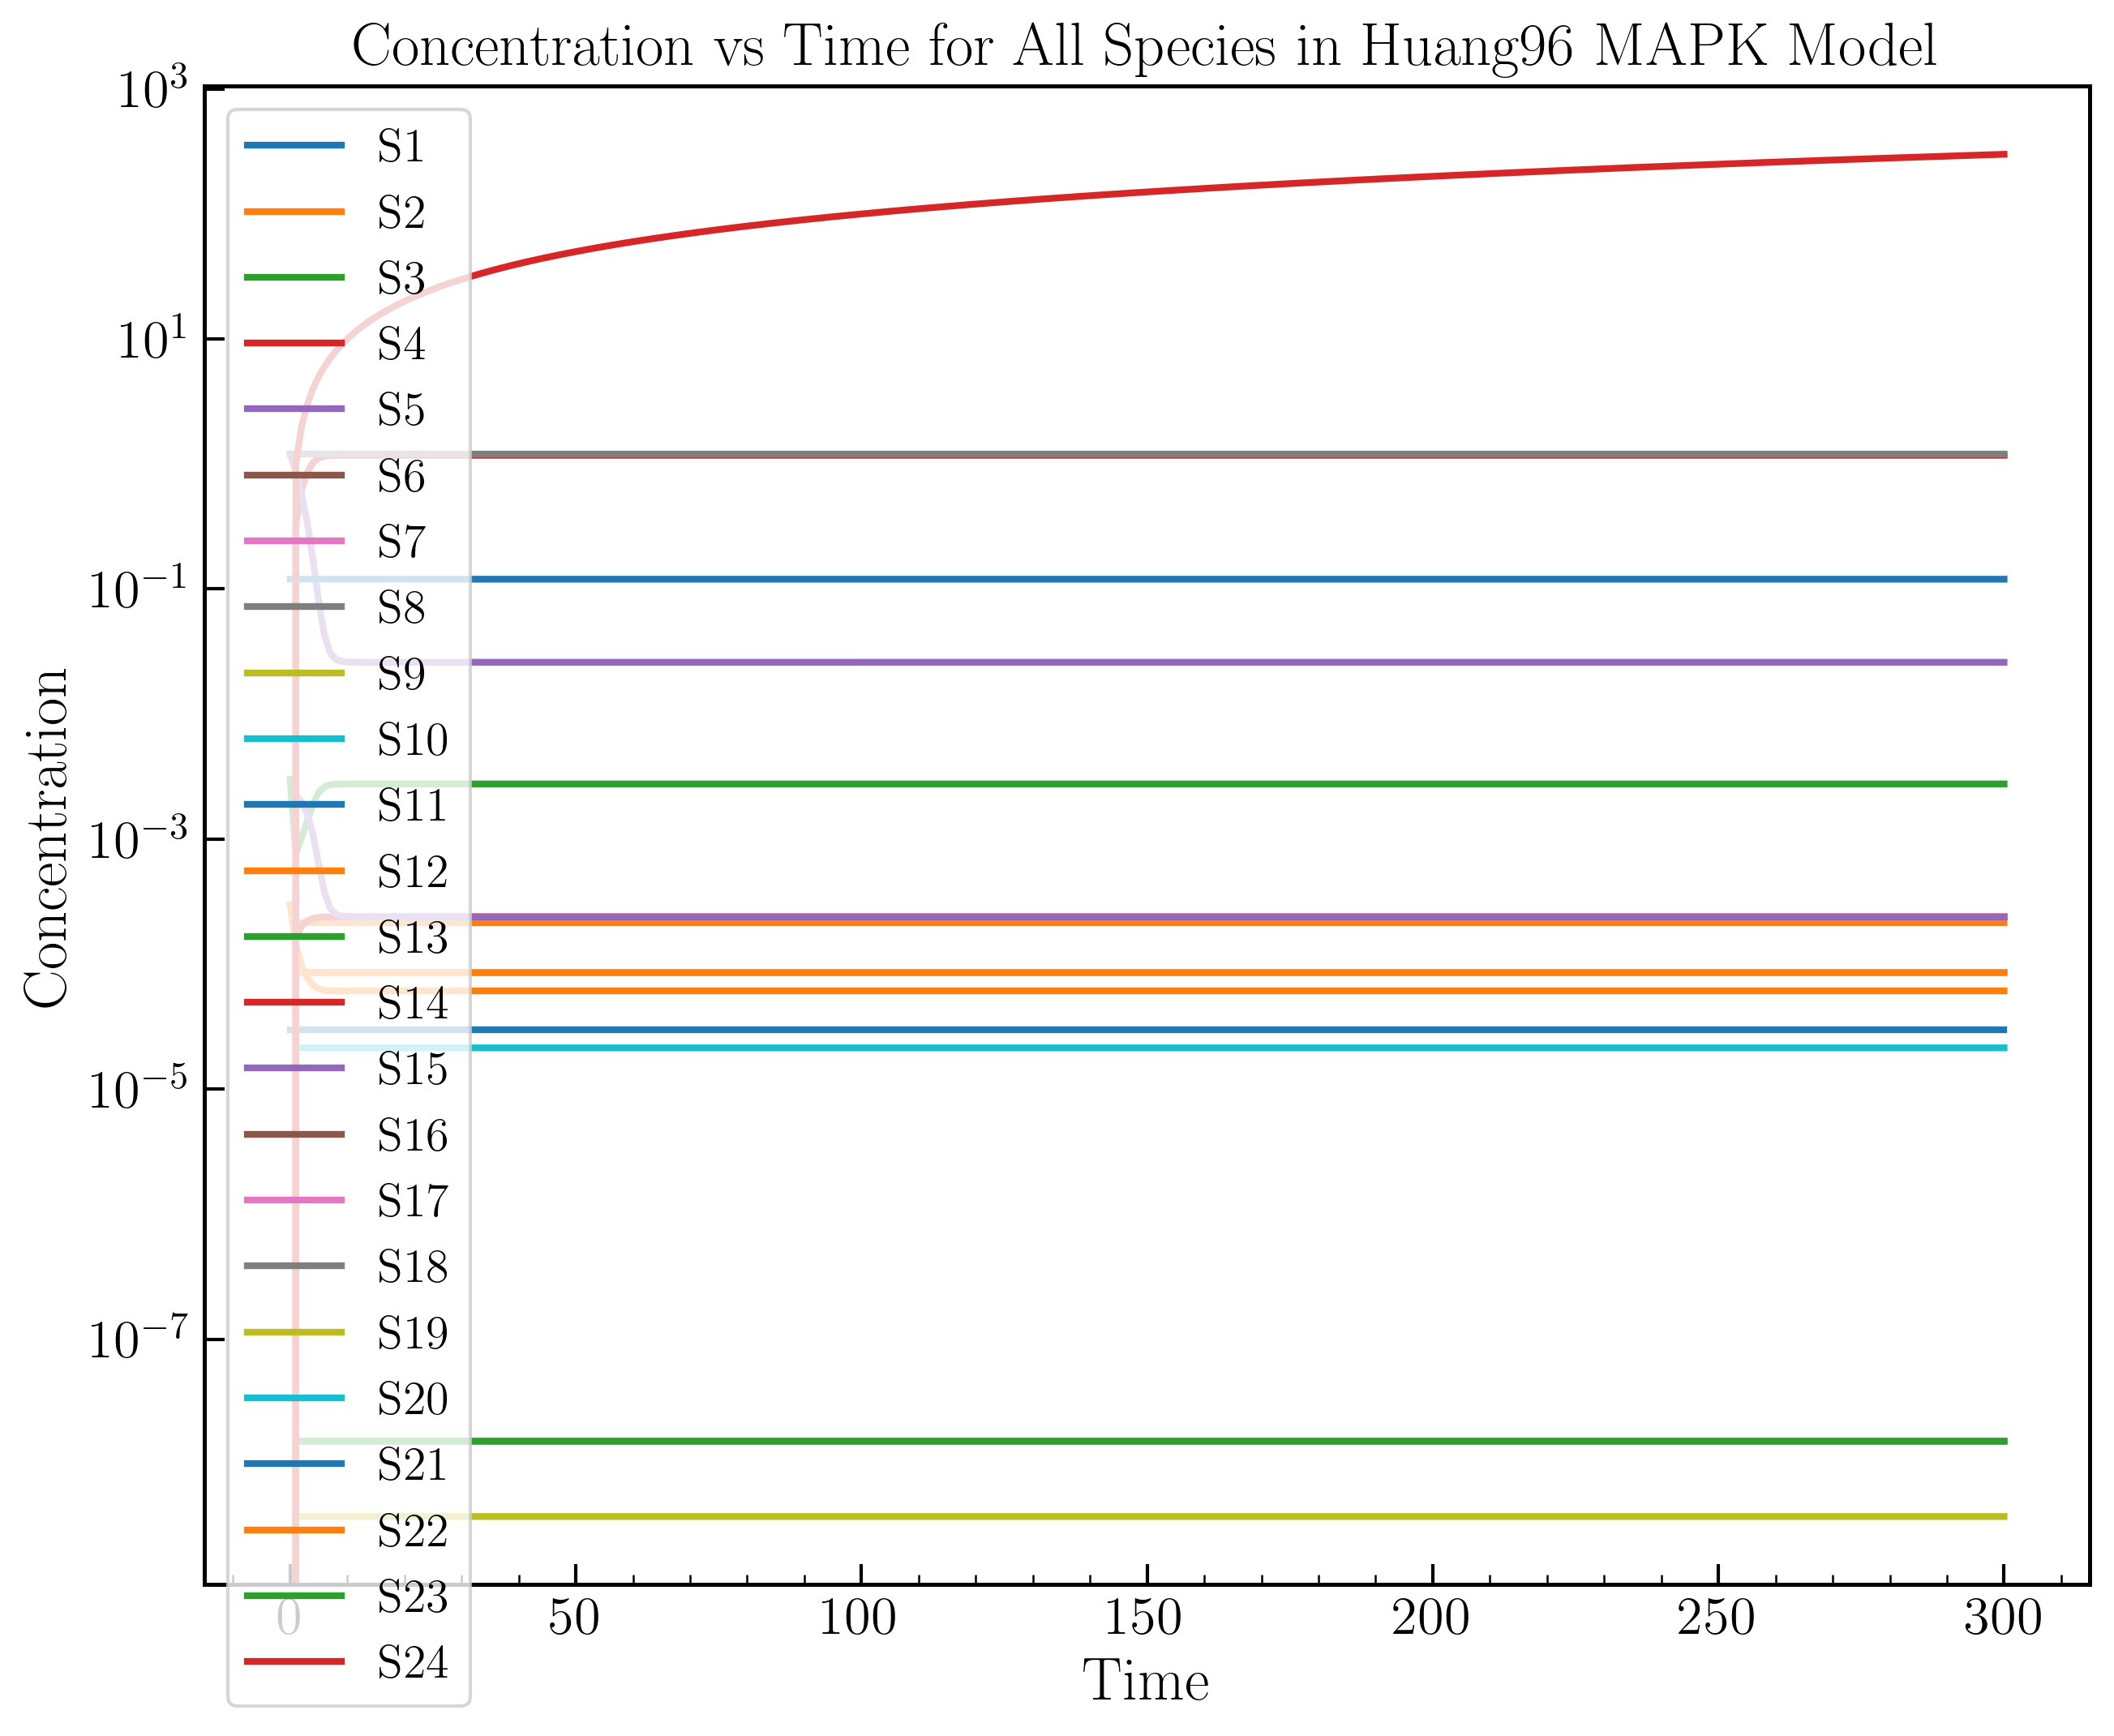

In [25]:
sol = solve_func_huang96_mapk(y0_2,
                             t_span=(0, 300),
                                t_eval=np.linspace(0, 300, 301),
                                arguments={
    "compartment": 1.0,
    "a_pars": 1000.0,
    "d_pars": 150.0,
    "k_pars": 150.0,
})
# Plot all species
plt.figure(figsize=(10, 8))
for i in range(24):
    plt.plot(sol.t, sol.y[i], lw=2, label=f'S{i+1}')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for All Species in Huang96 MAPK Model')
plt.legend()
plt.show()

## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [75]:
id_to_subject = {
    0: "A",
    1: "B",
    2: "AB",
    3: "B*"
}

df = pd.DataFrame(res_tab_complex['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df

,loop,length,sign,loop_subject
8,"(0, 0)",1,-1,"(A, A)"
9,"(1, 1)",1,-1,"(B, B)"
0,"(0, 1, 0)",2,1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
6,"(1, 2, 1)",2,1,"(B, AB, B)"
7,"(1, 3, 1)",2,1,"(B, B*, B)"
1,"(0, 1, 2, 0)",3,-1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"
4,"(0, 3, 1, 0)",3,1,"(A, B*, B, A)"
5,"(0, 3, 1, 2, 0)",4,-1,"(A, B*, B, AB, A)"


### 3.2. Represent regulation relationship from Jacobian matrix

In [76]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

print("\nRegulation information for unstimulated conditions:")

regulation_info = pd.DataFrame(signed_jacobian_un, columns=[id_to_subject[i] for i in range(signed_jacobian_un.shape[1])], index=[id_to_subject[i] for i in range(signed_jacobian_un.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['from', 'to', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info


Regulation information for unstimulated conditions:


,from,to,regulation,regulation_words
0,A,A,-1.0,inhibition (negative)
1,A,B,-1.0,inhibition (negative)
2,A,AB,1.0,activation (positive)
3,A,B*,0.0,no regulation
4,B,A,-1.0,inhibition (negative)
5,B,B,-1.0,inhibition (negative)
6,B,AB,1.0,activation (positive)
7,B,B*,1.0,activation (positive)
8,AB,A,1.0,activation (positive)
9,AB,B,1.0,activation (positive)


### 3.3. Loop Summary in more detail

In [77]:
# Given dataframe from 3.1 named `df`
df

,loop,length,sign,loop_subject
8,"(0, 0)",1,-1,"(A, A)"
9,"(1, 1)",1,-1,"(B, B)"
0,"(0, 1, 0)",2,1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
6,"(1, 2, 1)",2,1,"(B, AB, B)"
7,"(1, 3, 1)",2,1,"(B, B*, B)"
1,"(0, 1, 2, 0)",3,-1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"
4,"(0, 3, 1, 0)",3,1,"(A, B*, B, A)"
5,"(0, 3, 1, 2, 0)",4,-1,"(A, B*, B, AB, A)"


In [78]:
# Loop summary (A different way)
loop_summary = df.groupby('length').agg(
    num_loops=('loop', 'count'),
    loops=('loop_subject', lambda x: list(x))
).reset_index()
loop_summary

,length,num_loops,loops
0,1,2,"[(A, A), (B, B)]"
1,2,4,"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]"
2,3,3,"[(A, B, AB, A), (A, AB, B, A), (A, B*, B, A)]"
3,4,1,"[(A, B*, B, AB, A)]"


In [79]:
# make an extended loop summary with added information: 'num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative'
# Loop positive if sign is positive, negative if sign is negative
def count_loop_types(loop_subjects, regulation_info):
    num_positive = 0
    num_negative = 0
    loops_positive = []
    loops_negative = []
    
    for loop in loop_subjects:
        sign = 1
        for i in range(len(loop)):
            from_node = loop[i]
            to_node = loop[(i + 1) % len(loop)]
            regulation = regulation_info[
                (regulation_info['from'] == from_node) & 
                (regulation_info['to'] == to_node)
            ]['regulation'].values[0]
            sign *= regulation
        if sign > 0:
            num_positive += 1
            loops_positive.append(loop)
        else:
            num_negative += 1
            loops_negative.append(loop)
    return num_positive, num_negative, loops_positive, loops_negative
loop_summary_extended = loop_summary.copy()
loop_summary_extended[['num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative']] = loop_summary_extended['loops'].apply(
    lambda x: pd.Series(count_loop_types(x, regulation_info))
)
loop_summary_extended

,length,num_loops,loops,num_loops_positive,num_loops_negative,loops_positive,loops_negative
0,1,2,"[(A, A), (B, B)]",2,0,"[(A, A), (B, B)]",[]
1,2,4,"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]",0,4,[],"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]"
2,3,3,"[(A, B, AB, A), (A, AB, B, A), (A, B*, B, A)]",2,1,"[(A, B, AB, A), (A, AB, B, A)]","[(A, B*, B, A)]"
3,4,1,"[(A, B*, B, AB, A)]",0,1,[],"[(A, B*, B, AB, A)]"


In [80]:
# Columns can be rearranged based on preference
cols = ['length', 'num_loops', 'num_loops_positive', 'num_loops_negative', 'loops', 'loops_positive', 'loops_negative']
loop_summary_extended = loop_summary_extended[cols]
loop_summary_extended

,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
0,1,2,2,0,"[(A, A), (B, B)]","[(A, A), (B, B)]",[]
1,2,4,0,4,"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]",[],"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]"
2,3,3,2,1,"[(A, B, AB, A), (A, AB, B, A), (A, B*, B, A)]","[(A, B, AB, A), (A, AB, B, A)]","[(A, B*, B, A)]"
3,4,1,0,1,"[(A, B*, B, AB, A)]",[],"[(A, B*, B, AB, A)]"
